# S&P 500 과거 데이터 분석

2000년 1월부터 2019년 12월까지의 S&P 500 데이터를 클렌징하고, 종가 추이와 연도별·월별 통계, 이동평균, 위험 지표를 분석합니다.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CSV_PATH = Path(r"c:\work\S&P 500 과거 데이터.csv")
START_DATE = "2000-01-01"
END_DATE = "2019-12-31"

def to_number(value):
    if pd.isna(value) or str(value).strip() == "":
        return float("nan")
    return float(str(value).replace(",", "").replace("%", "").strip())

raw_data = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
cleaned_data = raw_data.copy()
cleaned_data["날짜"] = pd.to_datetime(
    cleaned_data["날짜"].astype(str).str.replace(" ", "", regex=False),
    errors="coerce",
)

numeric_columns = ["종가", "시가", "고가", "저가", "거래량", "변동 %"]
for column in numeric_columns:
    cleaned_data[column] = cleaned_data[column].map(to_number)

cleaned_data = cleaned_data.dropna(subset=["날짜", "종가"])
duplicate_count = cleaned_data.duplicated(subset=["날짜"]).sum()
cleaned_data = cleaned_data.drop_duplicates(subset=["날짜"], keep="first")
cleaned_data = cleaned_data.sort_values("날짜").reset_index(drop=True)

data = cleaned_data.loc[cleaned_data["날짜"].between(START_DATE, END_DATE)].copy()
data["연도"] = data["날짜"].dt.year
data["월"] = data["날짜"].dt.month
data["일간 수익률(%)"] = data["종가"].pct_change().mul(100)
data["20일 이동평균"] = data["종가"].rolling(20).mean()
data["60일 이동평균"] = data["종가"].rolling(60).mean()

data["누적 최고 종가"] = data["종가"].cummax()
data["고점 대비 하락률(%)"] = (data["종가"] / data["누적 최고 종가"] - 1).mul(100)

print("원본 데이터 크기:", raw_data.shape)
print("분석 기간:", data["날짜"].min().date(), "~", data["날짜"].max().date())
print("분석 데이터 크기:", data.shape)
print("중복 날짜 수:", duplicate_count)
print("[결측치]")
print(data.isna().sum().loc[lambda values: values.gt(0)])


원본 데이터 크기: (5000, 7)
분석 기간: 2000-01-03 ~ 2019-11-14
분석 데이터 크기: (5000, 14)
중복 날짜 수: 0
[결측치]
거래량          5000
일간 수익률(%)       1
20일 이동평균       19
60일 이동평균       59
dtype: int64


In [4]:
print("[기술 통계]")
display(data[["종가", "시가", "고가", "저가", "일간 수익률(%)"]].describe().round(2))

annual_analysis = data.groupby("연도").agg(
    연초_종가=("종가", "first"),
    연말_종가=("종가", "last"),
    연중_최고가=("고가", "max"),
    연중_최저가=("저가", "min"),
    평균_종가=("종가", "mean"),
    거래일수=("날짜", "count"),
)
annual_analysis["연간 수익률(%)"] = (annual_analysis["연말_종가"] / annual_analysis["연초_종가"] - 1).mul(100)
print("\n[연도별 분석]")
display(annual_analysis.round(2))

print("[월별 평균 종가]")
display(data.groupby("월")["종가"].mean().round(2).to_frame("평균 종가"))

print("[위험 지표]")
print(f"최대 낙폭(%): {data['고점 대비 하락률(%)'].min():.2f}")
print(f"일간 수익률 표준편차(%): {data['일간 수익률(%)'].std():.2f}")

[기술 통계]


,종가,시가,고가,저가,일간 수익률(%)
count,5000.00,5000.00,5000.00,5000.00,4999.00
mean,1565.18,1564.99,1573.89,1555.38,0.02
std,574.25,574.16,574.94,573.24,1.19
min,676.50,679.30,695.30,666.80,-9.04
25%,1150.28,1150.45,1158.52,1140.95,-0.47
50%,1358.20,1358.05,1366.95,1347.00,0.05
75%,1973.38,1974.28,1983.38,1965.15,0.57
max,3096.60,3090.80,3102.60,3084.70,11.59



[연도별 분석]


,연초_종가,연말_종가,연중_최고가,연중_최저가,평균_종가,거래일수,연간 수익률(%)
연도,,,,,,,
2000,1455.2,1320.3,1553.1,1254.1,1427.22,252,-9.27
2001,1283.3,1148.1,1383.4,944.8,1194.18,248,-10.54
2002,1154.7,879.8,1177.0,768.6,993.94,252,-23.81
2003,909.0,1111.9,1112.6,788.9,965.23,252,22.32
2004,1108.5,1211.9,1217.3,1060.7,1130.65,252,9.33
2005,1202.1,1248.3,1275.8,1136.2,1207.23,252,3.84
2006,1268.8,1418.3,1431.8,1219.3,1310.46,251,11.78
2007,1416.6,1468.4,1576.1,1364.0,1477.19,251,3.66
2008,1447.2,903.2,1471.8,741.0,1220.04,253,-37.59


[월별 평균 종가]


,평균 종가
월,
1,1537.31
2,1535.93
3,1544.71
4,1567.21
5,1584.32
6,1576.97
7,1587.89
8,1585.84
9,1585.37


[위험 지표]
최대 낙폭(%): -56.78
일간 수익률 표준편차(%): 1.19


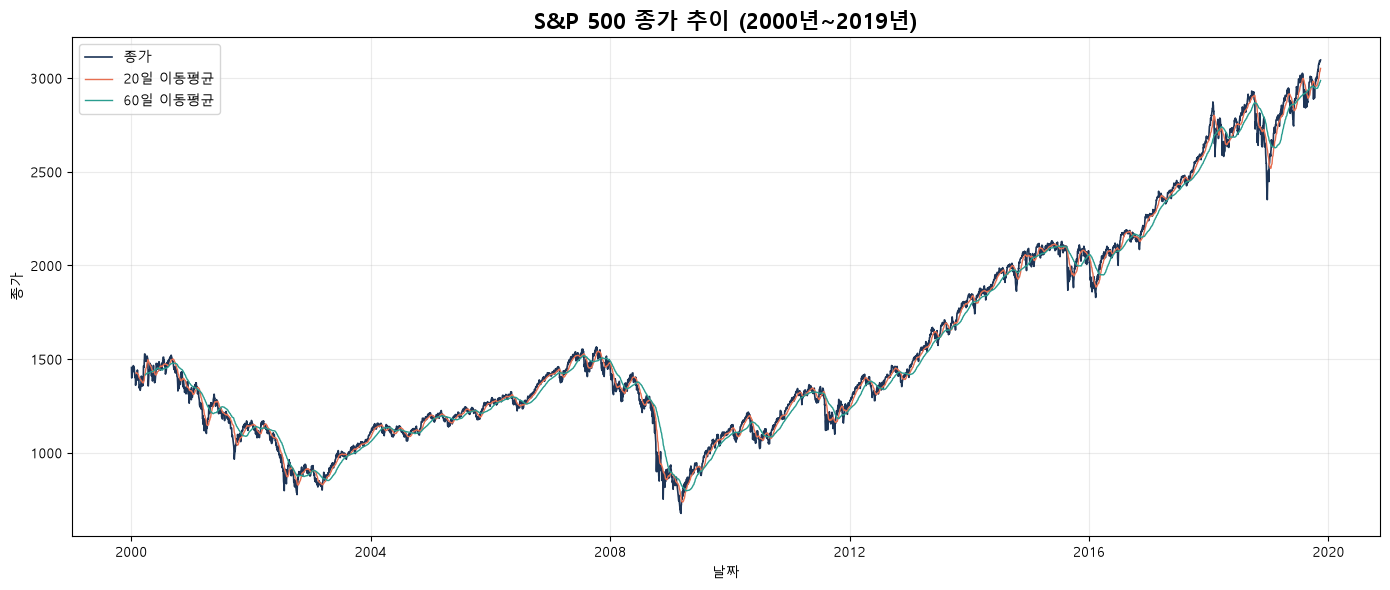

그래프 저장 완료: c:\work\sp500_close_2000_2019.png


In [5]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

figure, axis = plt.subplots(figsize=(14, 6))
axis.plot(data["날짜"], data["종가"], color="#1d3557", linewidth=1.2, label="종가")
axis.plot(data["날짜"], data["20일 이동평균"], color="#e76f51", linewidth=1, label="20일 이동평균")
axis.plot(data["날짜"], data["60일 이동평균"], color="#2a9d8f", linewidth=1, label="60일 이동평균")
axis.set_title("S&P 500 종가 추이 (2000년~2019년)", fontsize=16, fontweight="bold")
axis.set_xlabel("날짜")
axis.set_ylabel("종가")
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

output_path = Path.cwd() / "sp500_close_2000_2019.png"
figure.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"그래프 저장 완료: {output_path}")